# 3.1 Bifurcation analysis

Dynamical perspective

Leon Stefanovski (Charité University Medicine Berlin)  
Marius Pille (Berlin Institute of Health at Charité University
Medicine)  
Leon Martin (Berlin Institute of Health at Charité University Medicine)

## Goals

-   Build intuition for **fixed points, stability, and bifurcations**
    from scalar and 2D normal forms.
-   Run a **numerical continuation** in TVBO with one YAML and a single
    `exp.run(backend)` call.
-   Read a brain-relevant bifurcation diagram (Generic2dOscillator) and
    connect it to network-level regimes.

Bifurcation analysis tells us *how the qualitative behaviour of a model
changes when we move a parameter*. In TVBO every example below is just
**inline YAML + plotting** — no Fortran files, no scratch directories.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tvbo import Dynamics, Continuation, SimulationExperiment

## 1. Linear stability — sign of $a$ decides everything

The simplest dynamical system is

$$
\dot x = a\,x, \qquad x(0) = x_0, \qquad x(t) = x_0\,e^{a t}.
$$

For $a < 0$ the origin is a **stable** fixed point, for $a > 0$ it is
**unstable**, and $a = 0$ is the prototype of a **bifurcation**.

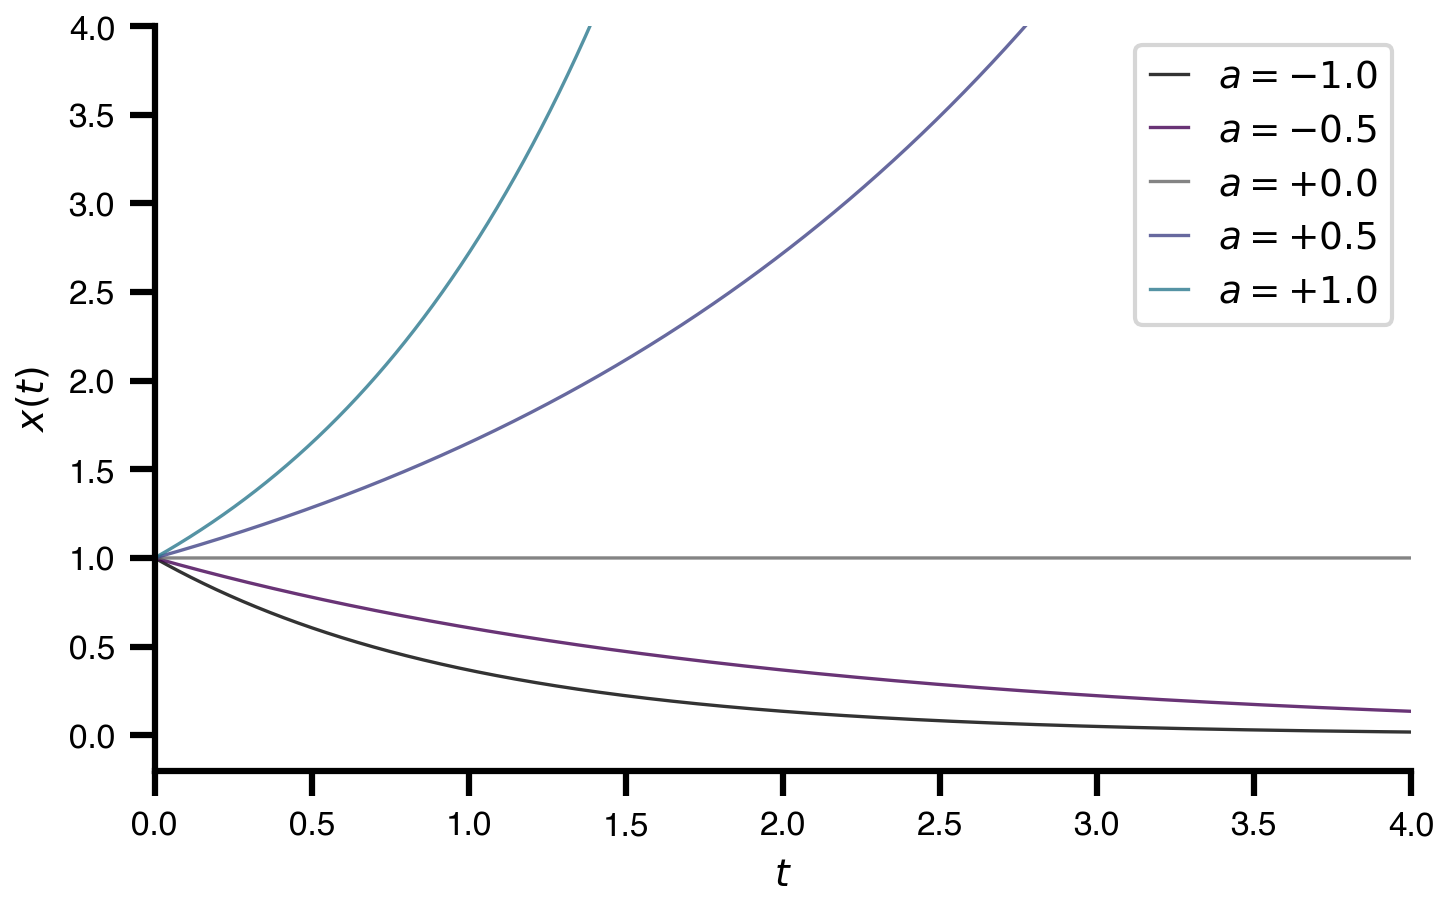

In [2]:
LIN = """
name: LinearScalar
parameters:
  a:
    name: a
    value: 1.0
state_variables:
  x:
    name: x
    domain:
      lo: -5.0
      hi: 5.0
    equation:
      lhs: Derivative(x, t)
      rhs: a*x
    initial_value: 1.0
"""

fig, ax = plt.subplots(figsize=(5, 3.2))
for a, c in zip([-1.0, -0.5, 0.0, 0.5, 1.0],
                ["C0", "C1", "0.4", "C2", "C3"]):
    dyn = Dynamics.from_string(LIN); dyn.parameters["a"].value = a
    dyn.plot("x", duration=4, dt=1e-3, ax=ax)
    ax.lines[-1].set_color(c); ax.lines[-1].set_label(f"$a = {a:+.1f}$")
ax.set(xlabel="$t$", ylabel="$x(t)$", xlim=(0, 4), ylim=(-0.2, 4.0))
ax.legend(handlelength=1, fontsize=9); plt.tight_layout(); plt.show()

The slope at $t = 0$ equals $a$ — its sign decides growth vs. decay. For
nonlinear systems $\dot x = f(x)$, stability of an equilibrium $x^*$ is
governed by the **Jacobian eigenvalues**
$J = \partial f/\partial x|_{x^*}$. Everything that follows is built
from this idea.

## 2. 2D phase portraits — node, saddle, focus, centre

For $\dot{\vec x} = A\vec x$ in 2D, the eigenvalues of $A$ classify the
origin. TVBO’s `kind="phaseplane"` overlays the vector field with both
nullclines and the detected fixed points.

Each system below is a complete, copy-pastable YAML. We feed it directly
to `Dynamics.from_string` — no helper functions, no string
interpolation.

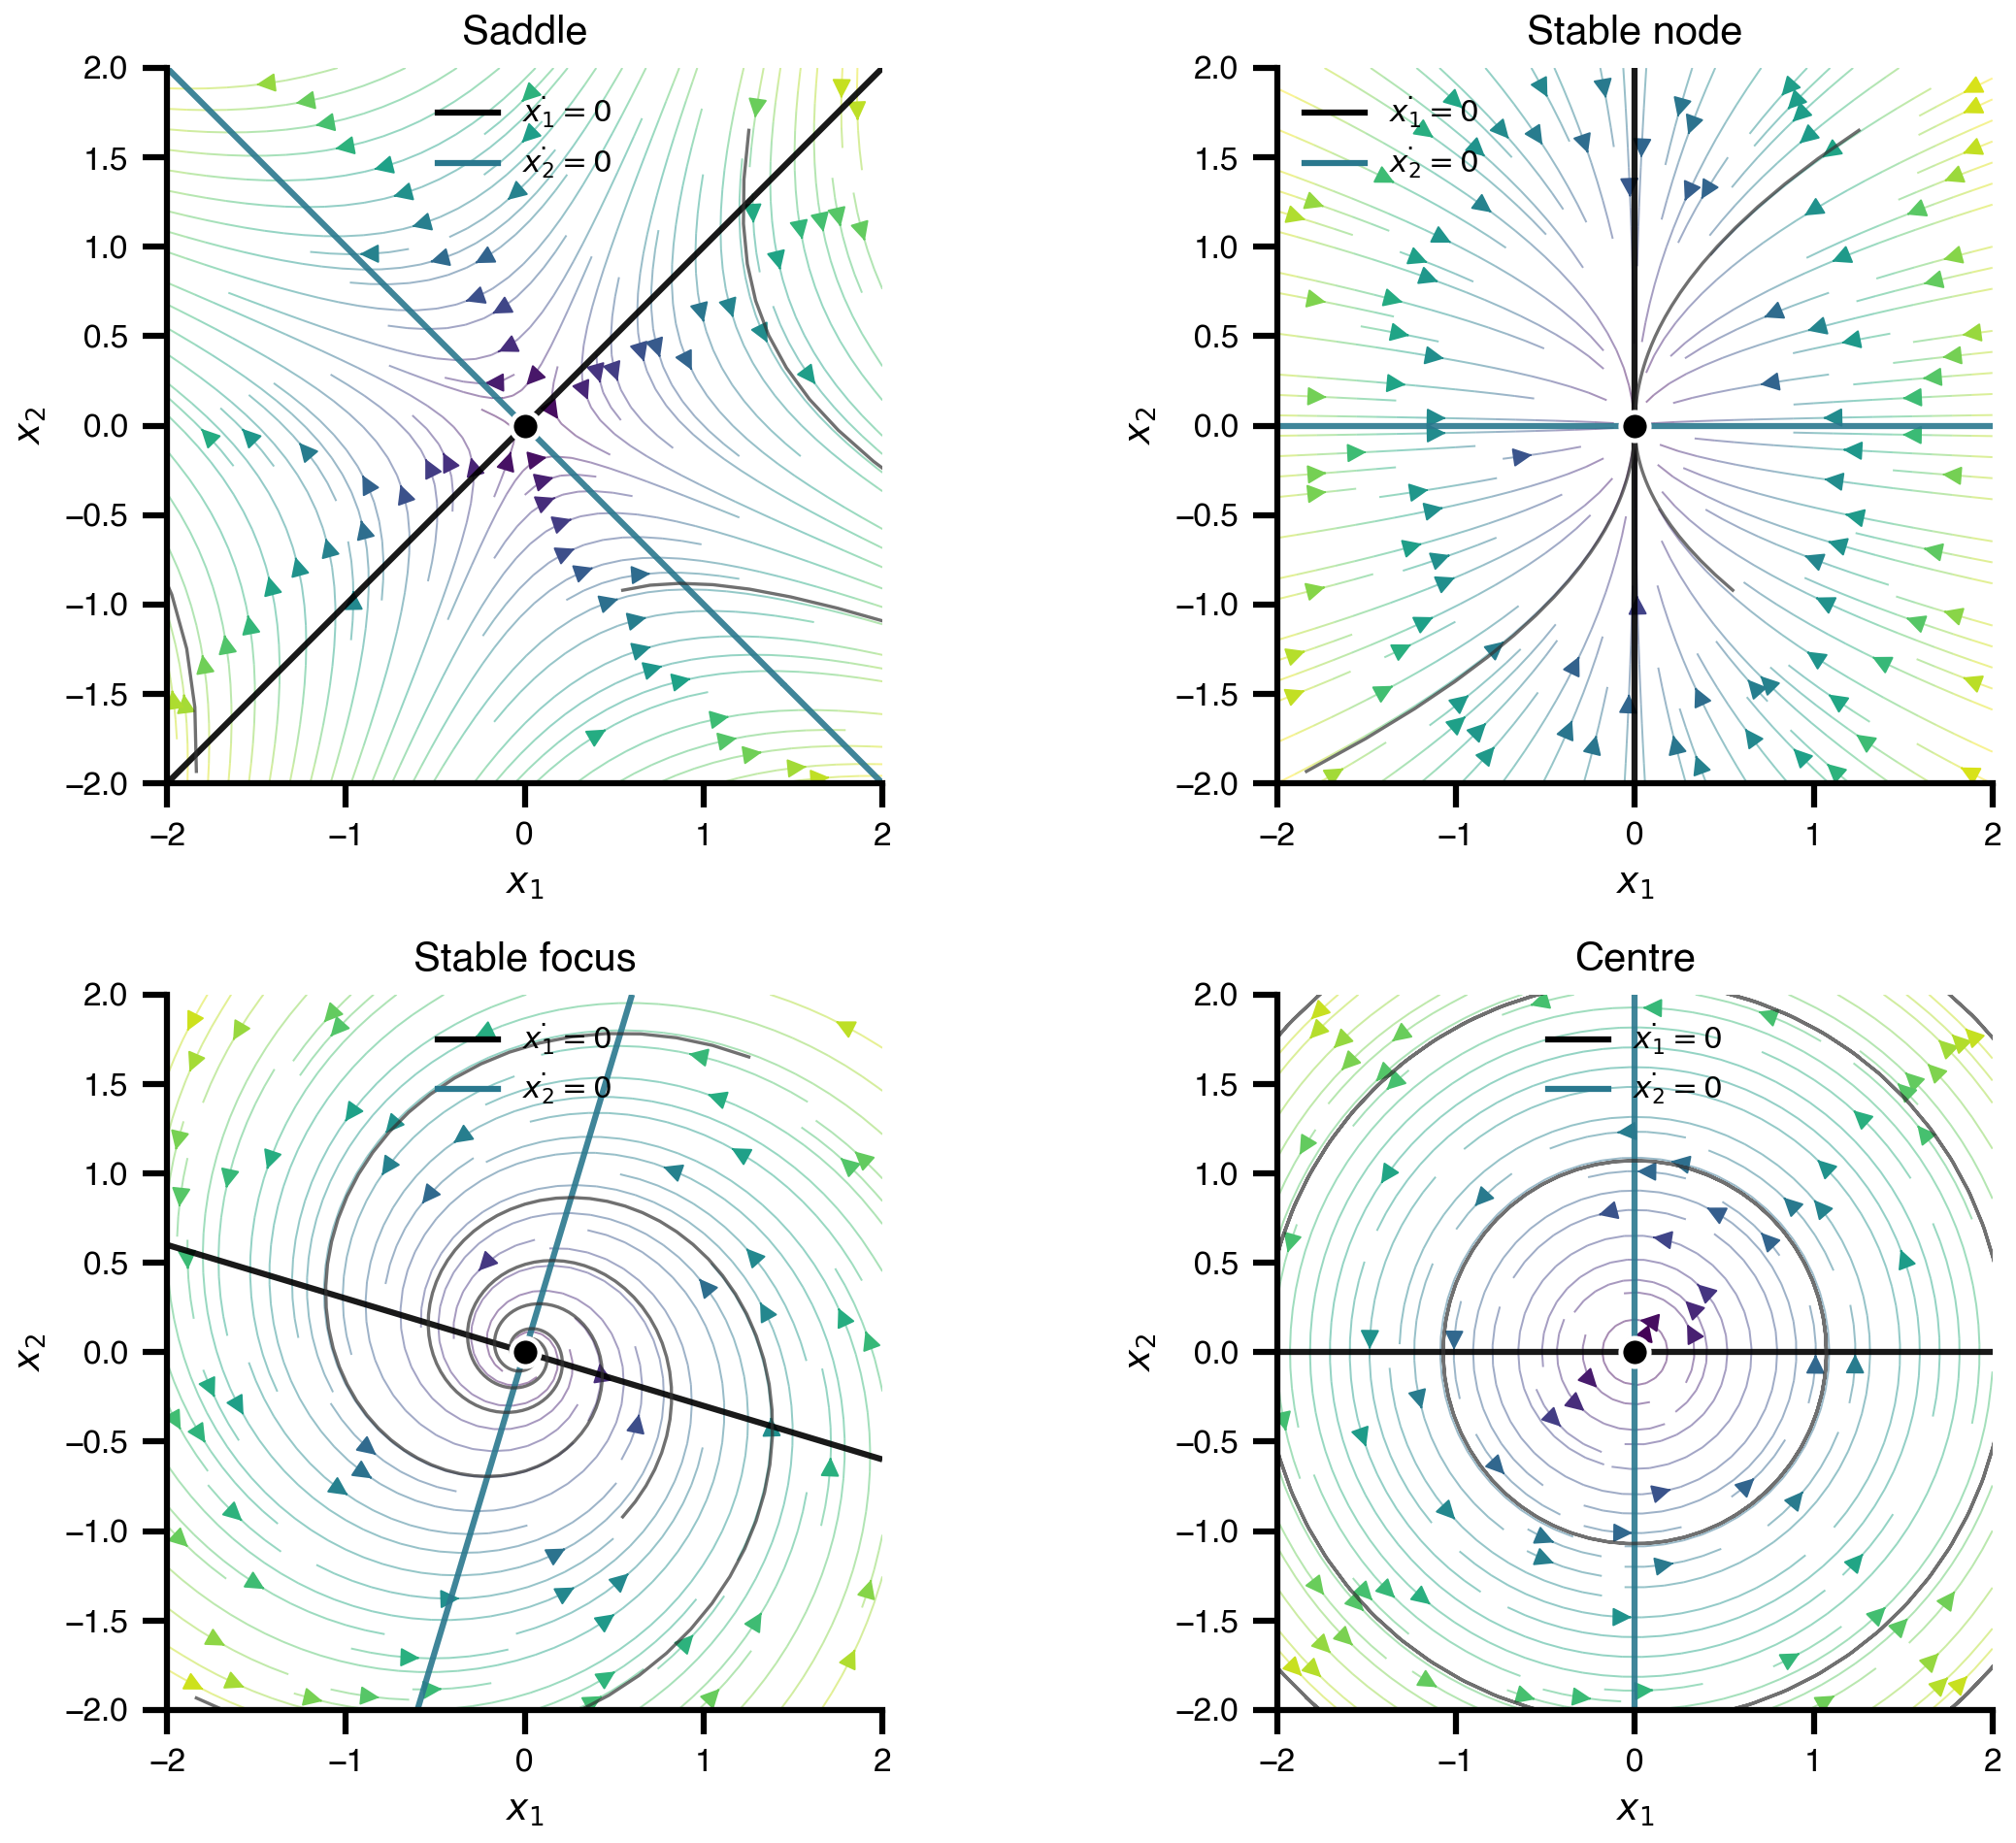

In [3]:
SADDLE = """
name: Saddle
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: x1 - x2
    initial_value: 1.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: -x1 - x2
    initial_value: 1.0
"""

STABLE_NODE = """
name: StableNode
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: -2*x1
    initial_value: 1.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: -x2
    initial_value: 1.0
"""

STABLE_FOCUS = """
name: StableFocus
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: -0.3*x1 - x2
    initial_value: 1.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: x1 - 0.3*x2
    initial_value: 1.0
"""

CENTRE = """
name: Centre
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: -x2
    initial_value: 1.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: x1
    initial_value: 1.0
"""

CASES = [
    ("Saddle",       SADDLE),
    ("Stable node",  STABLE_NODE),
    ("Stable focus", STABLE_FOCUS),
    ("Centre",       CENTRE),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 6.5))
for ax, (label, yml) in zip(axes.flat, CASES):
    dyn = Dynamics.from_string(yml)
    dyn.plot("x1", "x2", kind="phaseplane", ax=ax,
             grid_n=20, n_trajectories=3, duration=15)
    ax.set_title(label, fontsize=10)
plt.tight_layout(); plt.show()

Bifurcations occur when an eigenvalue of $A$ — or, locally, of the
Jacobian — **crosses the imaginary axis** as a parameter is varied.

## 3. The three codim-1 normal forms

We cover the canonical scalar bifurcations and let TVBO continue the
equilibrium branch *bidirectionally*. Each example is a self-contained
YAML pair (`Dynamics` + `Continuation`) passed straight into
`from_string`.

### Saddle-node — $\dot x = a - x^2$

Two equilibria collide and annihilate at $a = 0$. Beyond the fold *no
attractor* survives. This is the prototype for **regime shifts**.

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
CT: 1.143545 seconds (3.34 M allocations: 167.280 MiB, 3.65% gc time, 99.86% compilation time)
CT: 0.000399 seconds (7.60 k allocations: 318.734 KiB)

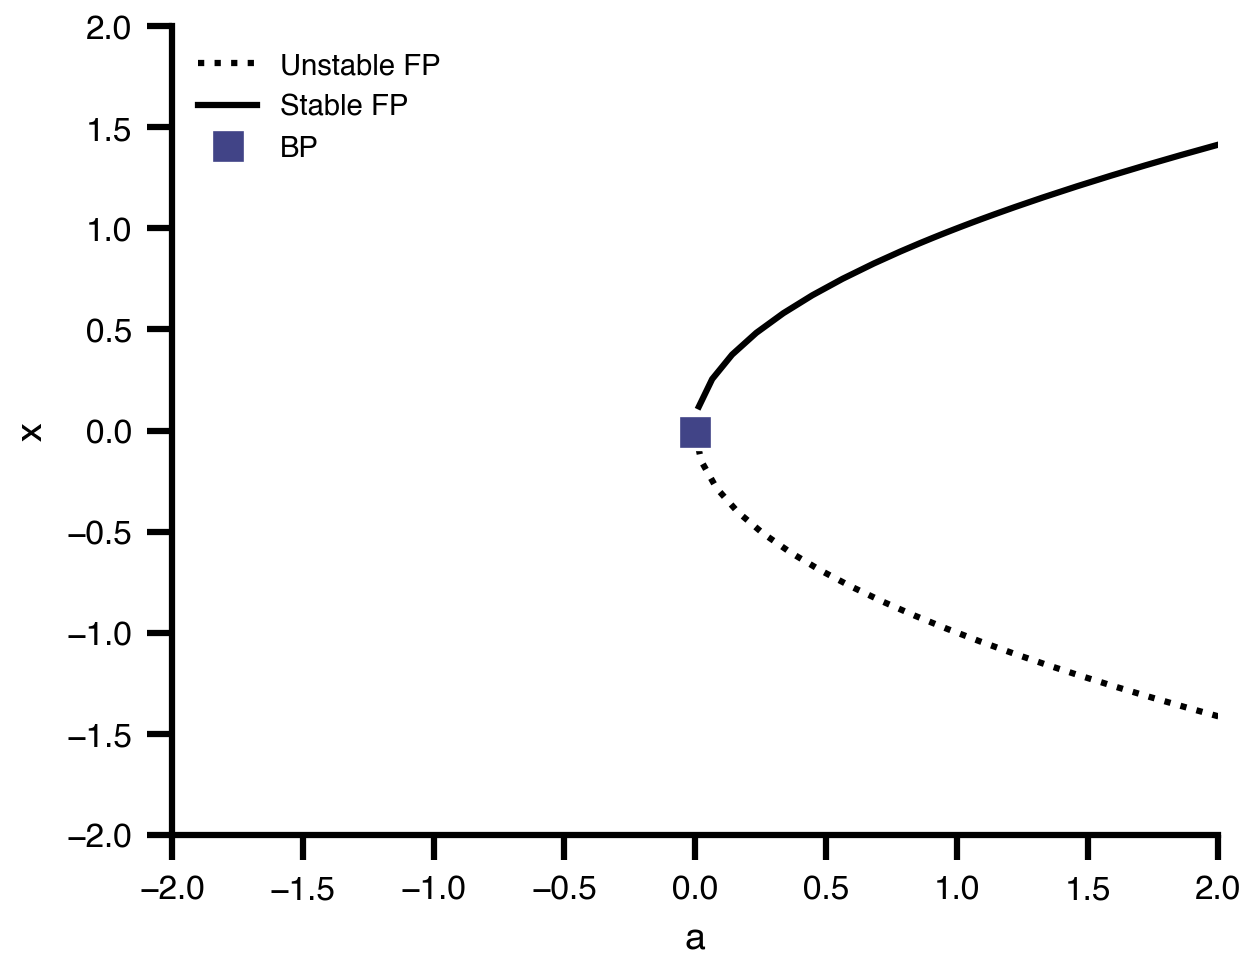

In [4]:
SADDLE_NODE = """
name: SaddleNode
parameters:
  a:
    name: a
    value: 1.0
state_variables:
  x:
    name: x
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x, t)
      rhs: a - x**2
    initial_value: 1.0
"""

SADDLE_NODE_CONT = """
name: saddle_node_cont
dynamics: SaddleNode
free_parameters:
  - name: a
    domain:
      lo: -2.0
      hi: 2.0
max_steps: 400
ds: 0.01
bothside: true
"""

exp_sn = SimulationExperiment(
    dynamics=Dynamics.from_string(SADDLE_NODE),
    continuations=[Continuation.from_string(SADDLE_NODE_CONT)],
)
exp_sn.run("bifurcationkit.jl").continuations["saddle_node_cont"].plot(VOI="x")
plt.gca().set(xlim=(-2, 2), ylim=(-2, 2)); plt.show()

### Pitchfork — $\dot x = a x - x^3$

Symmetry breaking: the trivial branch loses stability at $a = 0$ and a
pair of asymmetric branches $\pm\sqrt a$ emerges.

CT: 0.419261 seconds (808.13 k allocations: 39.327 MiB, 99.89% compilation time)
CT: 0.000267 seconds (4.43 k allocations: 189.656 KiB)

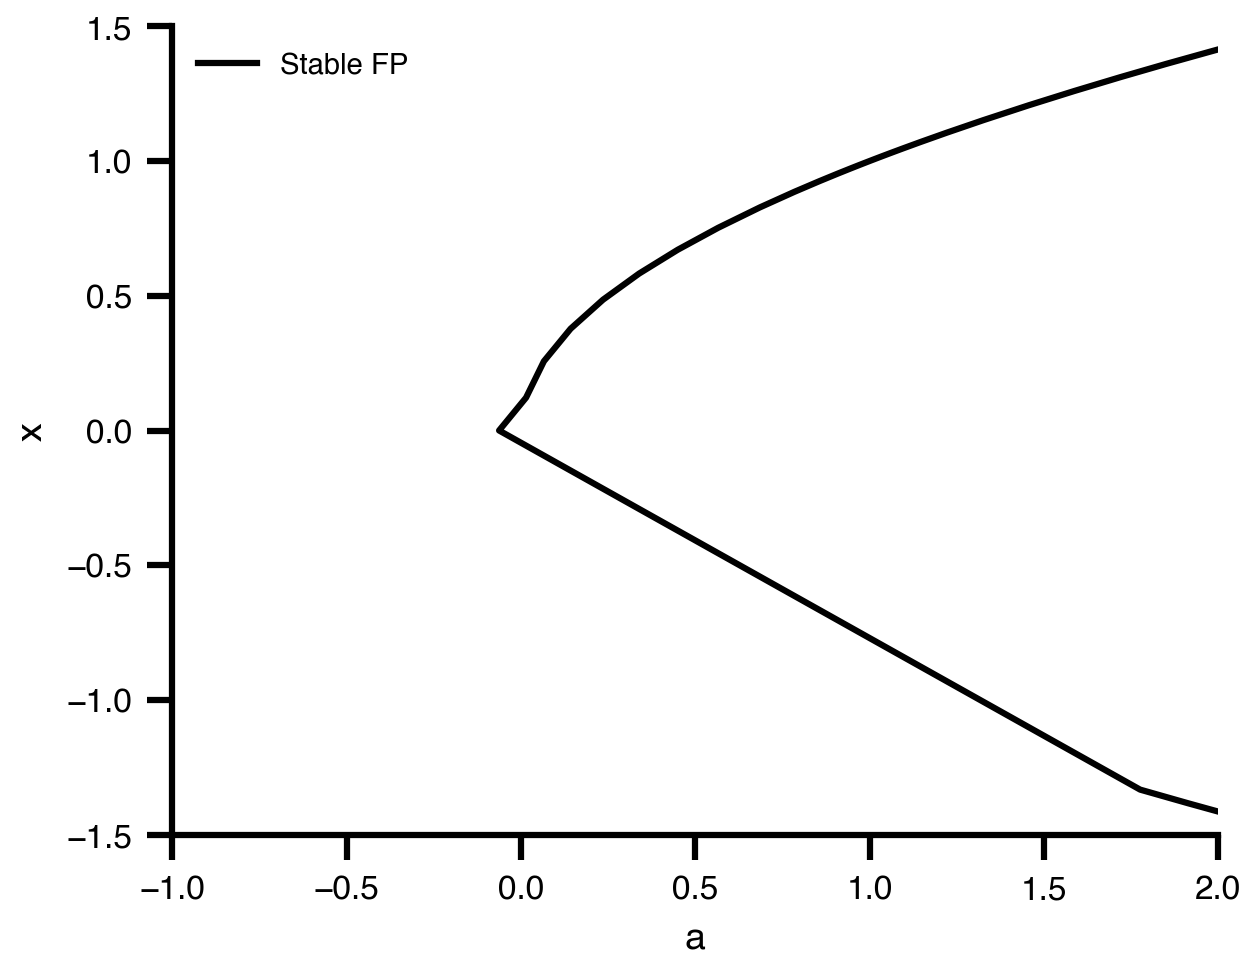

In [5]:
PITCHFORK = """
name: Pitchfork
parameters:
  a:
    name: a
    value: 1.0
state_variables:
  x:
    name: x
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x, t)
      rhs: a*x - x**3
    initial_value: 0.01
"""

PITCHFORK_CONT = """
name: pitchfork_cont
dynamics: Pitchfork
free_parameters:
  - name: a
    domain:
      lo: -2.0
      hi: 2.0
max_steps: 400
ds: 0.01
bothside: true
"""

exp_pf = SimulationExperiment(
    dynamics=Dynamics.from_string(PITCHFORK),
    continuations=[Continuation.from_string(PITCHFORK_CONT)],
)
exp_pf.run("bifurcationkit.jl").continuations["pitchfork_cont"].plot(VOI="x")
plt.gca().set(xlim=(-1, 2), ylim=(-1.5, 1.5)); plt.show()

### Hysteresis — $\dot x = a + x - x^3$

A small constant tilt unfolds the pitchfork into **two** saddle-nodes
framing a bistable region. Sweeping $a$ up then down traces a memory
loop.

CT: 0.453876 seconds (806.00 k allocations: 39.502 MiB, 99.88% compilation time)
CT: 0.000551 seconds (10.88 k allocations: 451.875 KiB)

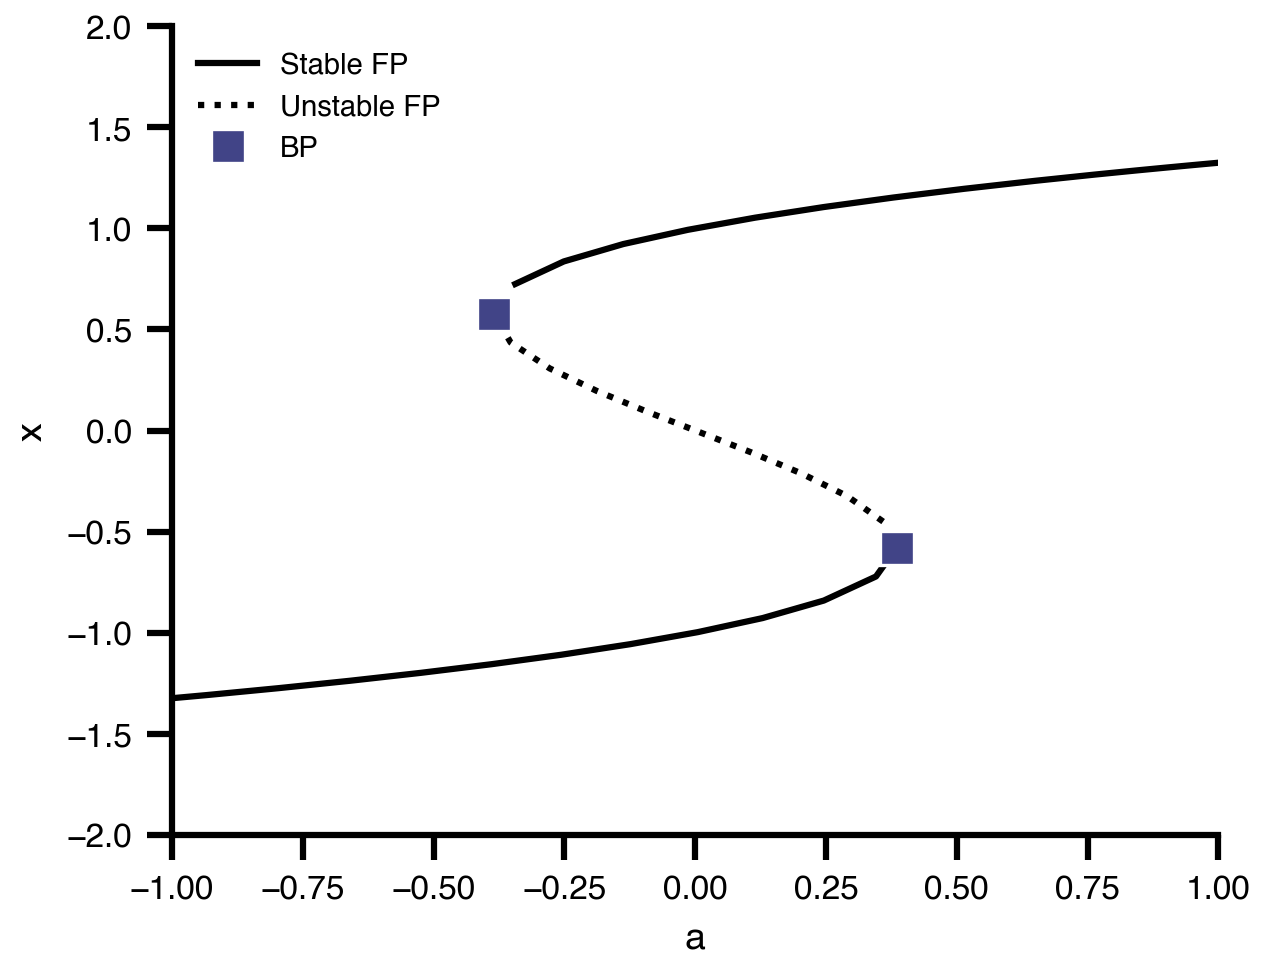

In [6]:
HYSTERESIS = """
name: Hysteresis
parameters:
  a:
    name: a
    value: 1.0
state_variables:
  x:
    name: x
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x, t)
      rhs: a + x - x**3
    initial_value: 1.0
"""

HYSTERESIS_CONT = """
name: hysteresis_cont
dynamics: Hysteresis
free_parameters:
  - name: a
    domain:
      lo: -1.5
      hi: 1.5
max_steps: 400
ds: 0.01
bothside: true
"""

exp_hy = SimulationExperiment(
    dynamics=Dynamics.from_string(HYSTERESIS),
    continuations=[Continuation.from_string(HYSTERESIS_CONT)],
)
exp_hy.run("bifurcationkit.jl").continuations["hysteresis_cont"].plot(VOI="x")
plt.gca().set(xlim=(-1, 1), ylim=(-2, 2)); plt.show()

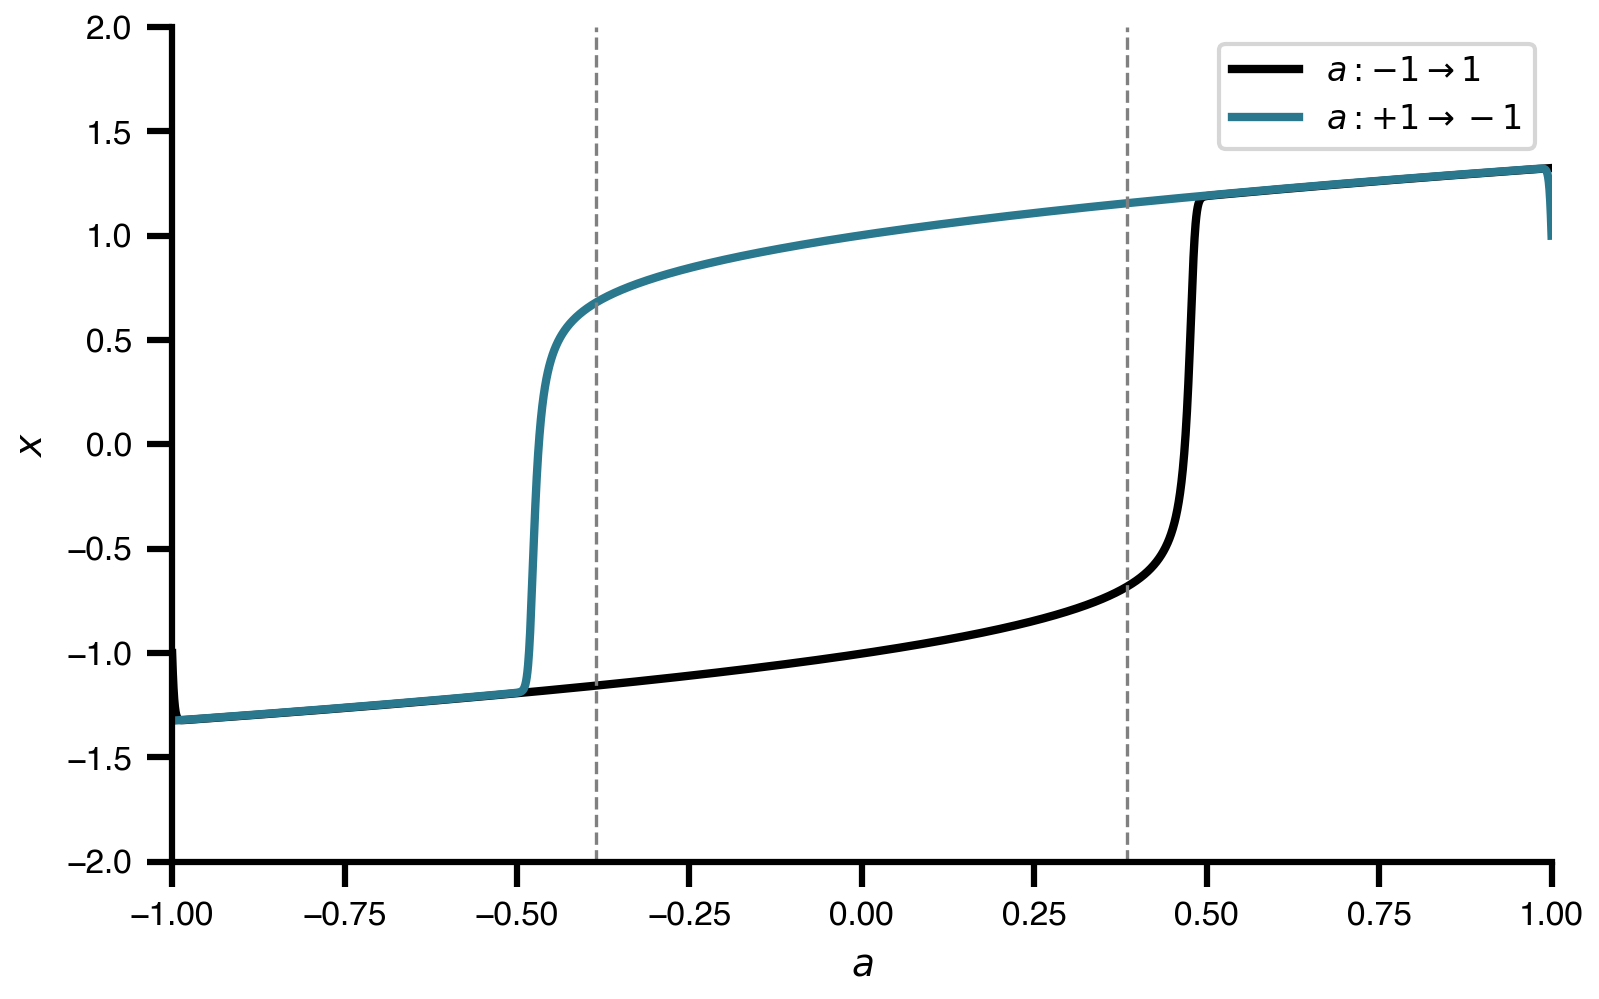

In [7]:
def sweep(a_start, a_end, n=4000, x0=1.0, dt=0.05):
    a_traj = np.linspace(a_start, a_end, n); x = np.empty(n); x[0] = x0
    for k in range(1, n):
        x[k] = x[k-1] + dt * (a_traj[k-1] + x[k-1] - x[k-1]**3)
    return a_traj, x

a_up, x_up   = sweep(-1.0, +1.0, x0=-1.0)
a_dn, x_dn   = sweep(+1.0, -1.0, x0=+1.0)
af = 2.0/(3.0*np.sqrt(3.0))

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(a_up, x_up, "C0", lw=2, label=r"$a:-1\to1$")
ax.plot(a_dn, x_dn, "C3", lw=2, label=r"$a:+1\to-1$")
ax.axvline(+af, color="0.5", ls="--", lw=0.8)
ax.axvline(-af, color="0.5", ls="--", lw=0.8)
ax.set(xlabel="$a$", ylabel="$x$", xlim=(-1, 1), ylim=(-2, 2))
ax.legend(); plt.tight_layout(); plt.show()

## 4. Hopf normal form — birth of an oscillation

In 2D, a **Hopf bifurcation** occurs when a pair of complex-conjugate
eigenvalues crosses the imaginary axis. A stable focus turns into an
unstable focus surrounded by a stable **limit cycle** of radius
$\sqrt a$.

$$
\dot x_1 = (a - x_1^2 - x_2^2)\,x_1 - w\,x_2, \qquad
\dot x_2 = (a - x_1^2 - x_2^2)\,x_2 + w\,x_1.
$$

In [8]:
HOPF = r"""
name: HopfNF
parameters:
  a:
    name: a
    value: 0.5
  w:
    name: w
    value: 1.0
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: (a - x1**2 - x2**2)*x1 - w*x2
    initial_value: 0.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: (a - x1**2 - x2**2)*x2 + w*x1
    initial_value: 0.0
"""

CONT_HOPF = """
name: hopf_in_a
dynamics: HopfNF
free_parameters:
  - name: a
    domain:
      lo: -2.0
      hi: 2.0
max_steps: 400
ds: 0.01
bothside: true
branches:
  - name: po_from_hopf
    source_point: "hopf:all"
    bothside: true
"""

dyn  = Dynamics.from_string(HOPF)
cont = Continuation.from_string(CONT_HOPF)
exp_hopf = SimulationExperiment(dynamics=dyn, continuations=[cont])
hopf = exp_hopf.run("bifurcationkit.jl").continuations["hopf_in_a"]

CT: 0.515503 seconds (883.62 k allocations: 42.973 MiB, 99.91% compilation time)
CT: 0.000153 seconds (2.14 k allocations: 191.859 KiB)
CT: 3.188254 seconds (3.80 M allocations: 546.509 MiB, 2.95% gc time, 91.49% compilation time)
CT: 0.167862 seconds (226.88 k allocations: 390.487 MiB, 7.80% gc time)

The 2D bifurcation diagram (`MIN`/`MAX` envelope of the limit cycle):

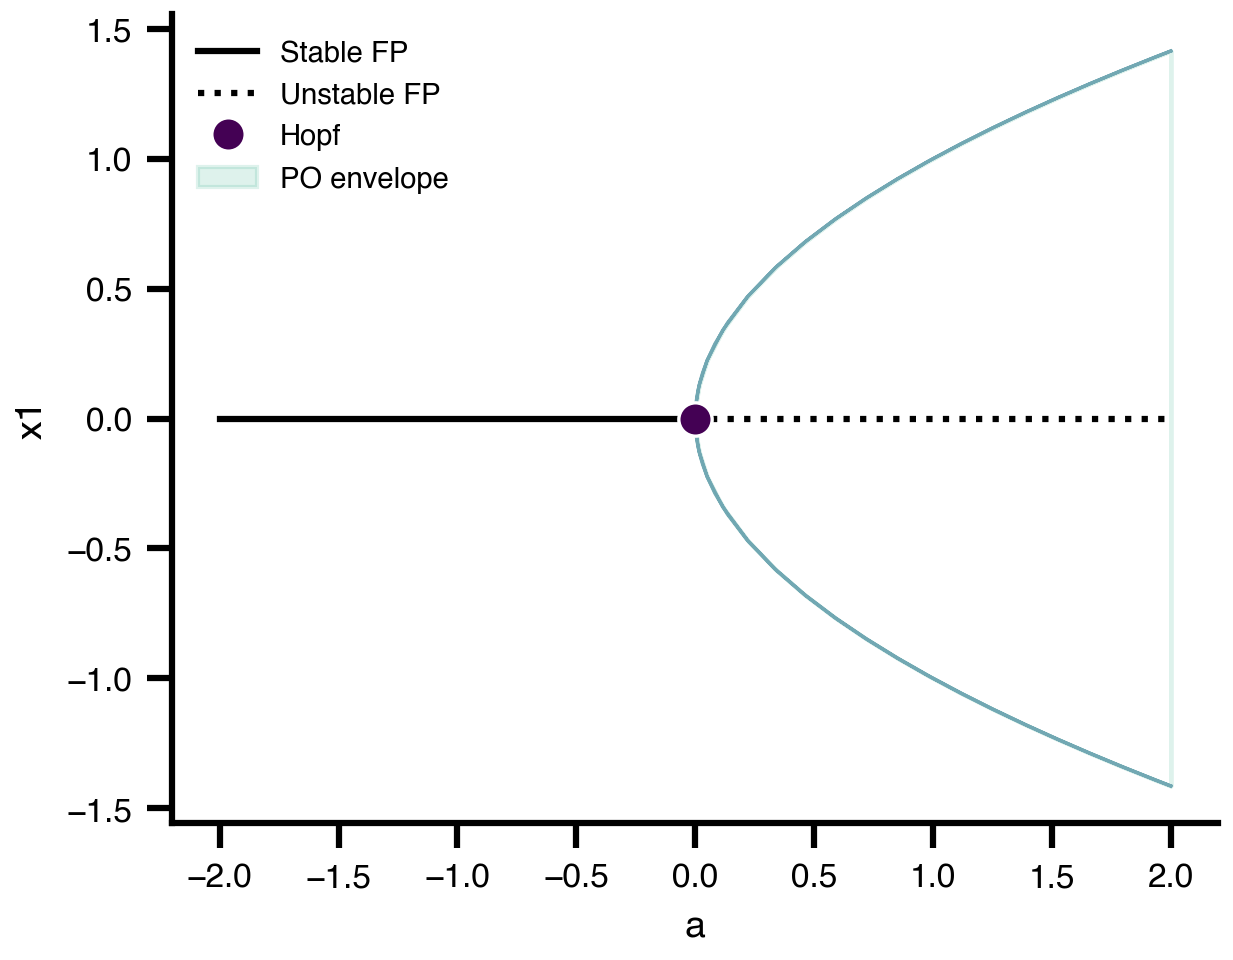

In [9]:
hopf.plot(VOI="x1"); plt.show()

The 3D view shows the equilibrium spine, the Hopf point, and the
limit-cycle **tube** whose radius grows like $\sqrt a$:

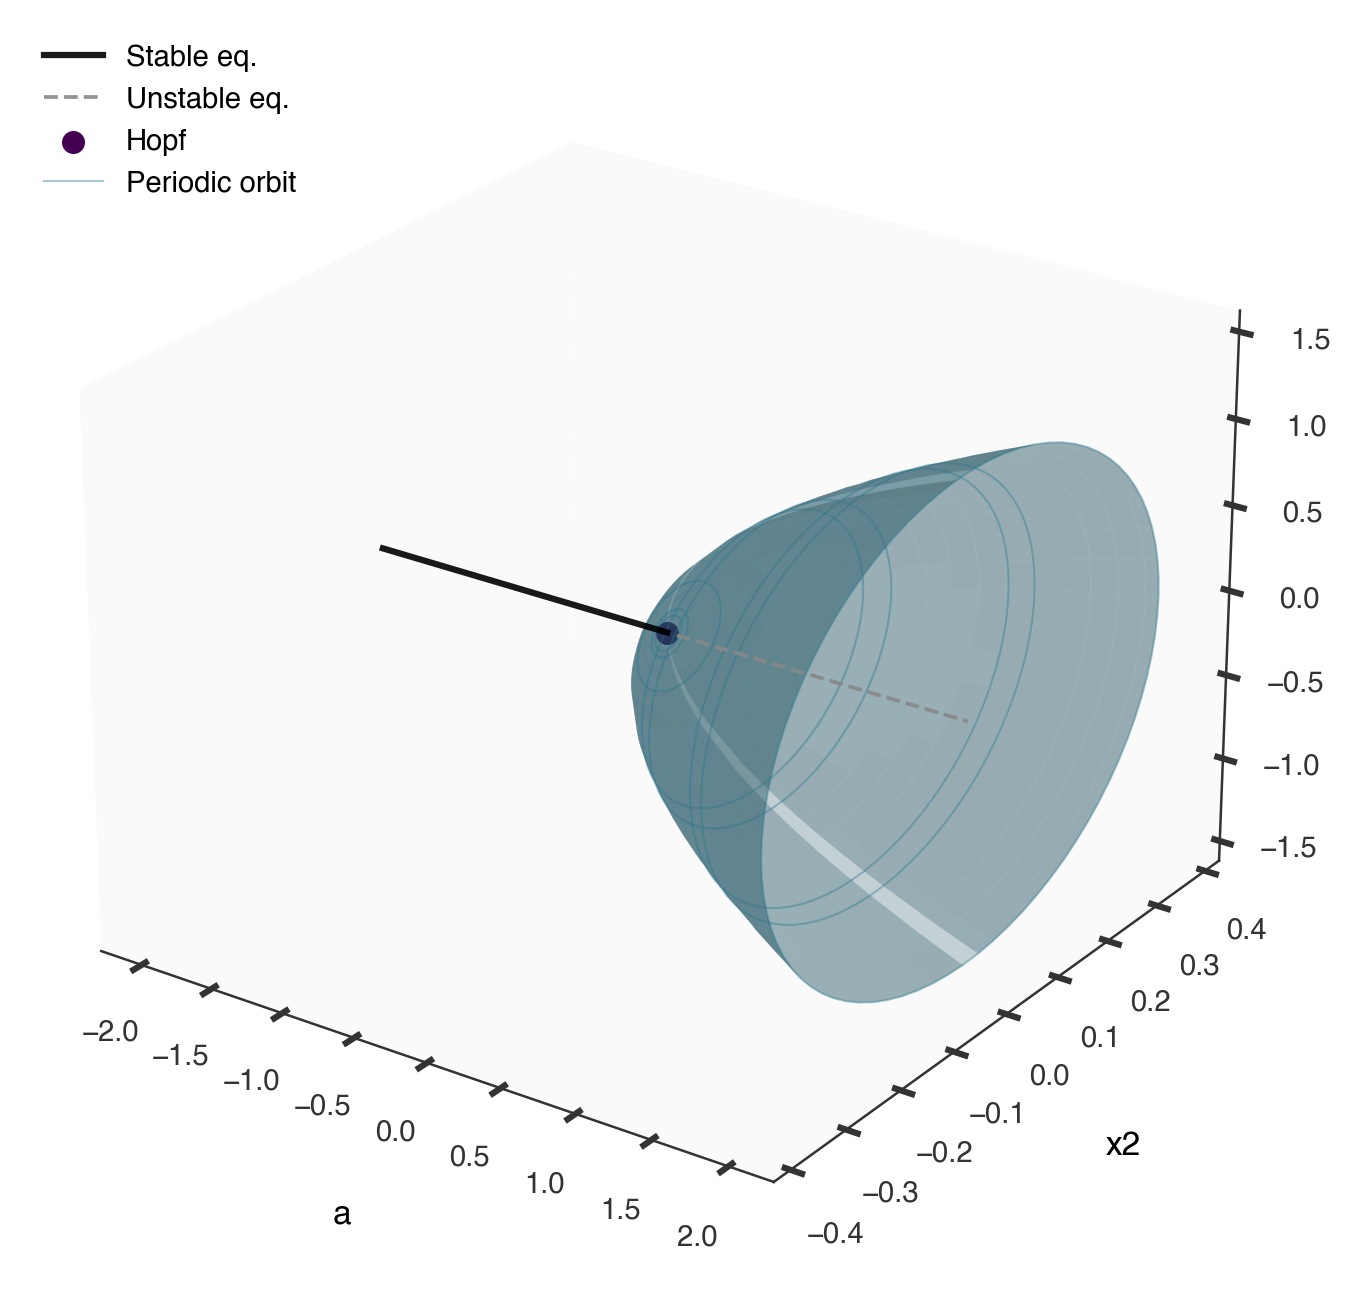

In [10]:
hopf.plot_3d(VOI="x1"); plt.show()

## 5. Numerical continuation in one paragraph

The backend (`bifurcationkit.jl`) tracks equilibria $f(x, a) = 0$ along
**arclength** $s$ instead of along $a$ directly. A
**predictor-corrector** scheme (tangent extrapolation + Newton on the
augmented system) walks past folds where $J$ becomes singular.
Bifurcations are flagged by sign changes in **test functions** ($\det J$
for folds, $\mathrm{Re}\,\lambda$ for Hopf, etc.). At a branch point the
corrector restarts in the eigenvector direction. This is **branch
switching**, and in TVBO it is requested declaratively:

``` yaml
branches:
  - name: po_from_hopf
    source_point: "hopf:all"
```

## 6. Brain-relevant: Generic2dOscillator

The same `Continuation` API drives a TVB neural-mass model. We sweep the
external input $I$ and let TVBO continue periodic orbits from every
detected Hopf point.

CT: 0.582853 seconds (907.12 k allocations: 44.923 MiB, 99.39% compilation time)
CT: 0.006897 seconds (16.19 k allocations: 1.187 MiB, 83.00% compilation time)
CT: 9.624644 seconds (7.54 M allocations: 7.533 GiB, 12.07% gc time, 31.75% compilation time)
CT: 3.412186 seconds (4.44 M allocations: 7.412 GiB, 25.10% gc time)
CT: 3.317667 seconds (4.80 M allocations: 7.762 GiB, 25.76% gc time, 2.85% compilation time)
CT: 3.086930 seconds (4.42 M allocations: 7.367 GiB, 27.02% gc time)

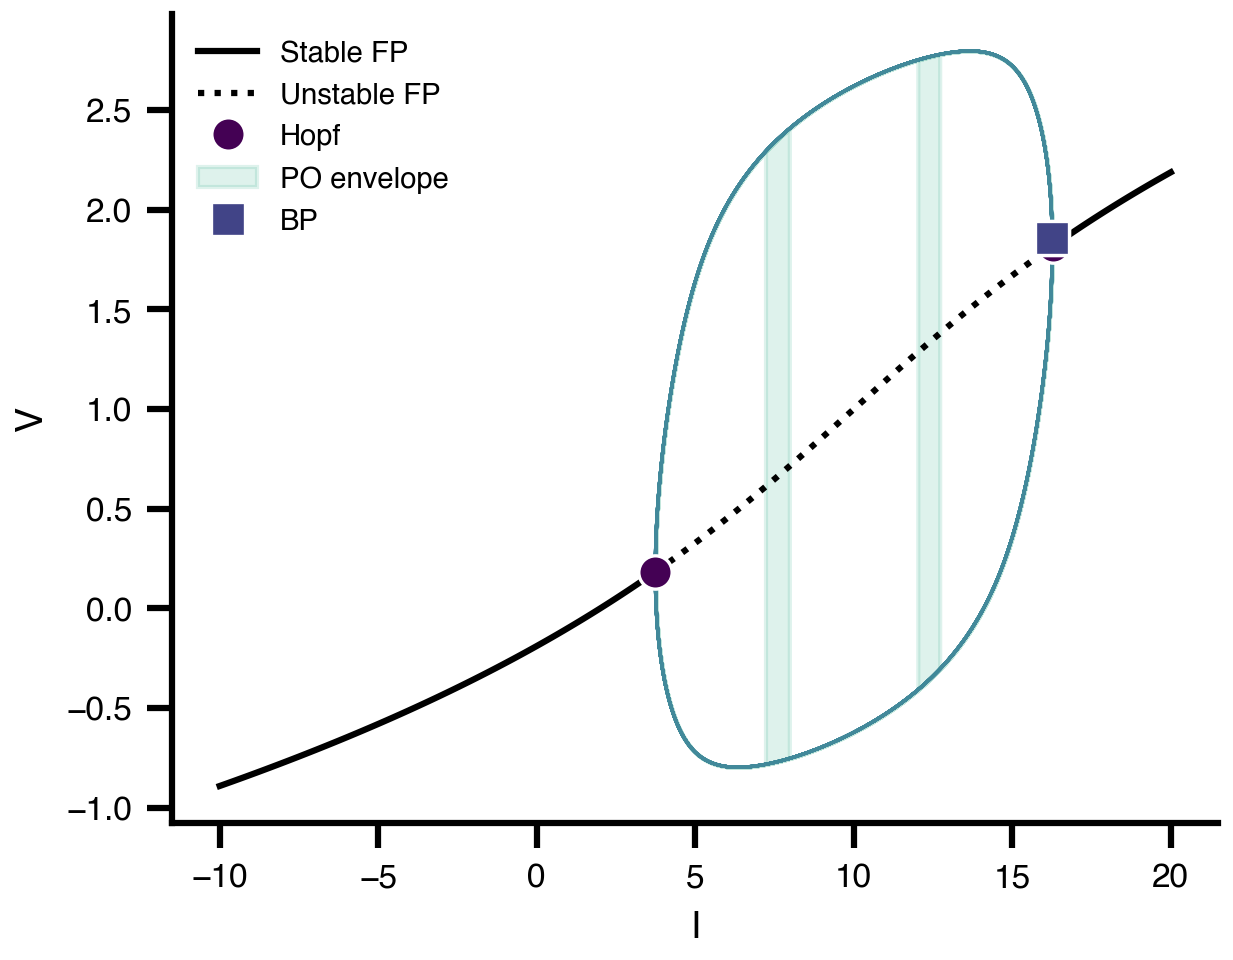

In [11]:
model = Dynamics.from_ontology("Generic2dOscillator")

cont = Continuation.from_string("""
name: g2d_in_I
dynamics: Generic2dOscillator
free_parameters:
  - name: I
    domain:
      lo: -10.0
      hi: 20.0
max_steps: 500
ds: 0.05
bothside: true
branches:
  - name: po_from_hopf
    source_point: "hopf:all"
    bothside: true
""")

exp_g2d = SimulationExperiment(dynamics=model, continuations=[cont])
g2d = exp_g2d.run("bifurcationkit.jl").continuations["g2d_in_I"]
g2d.plot(VOI="V"); plt.show()

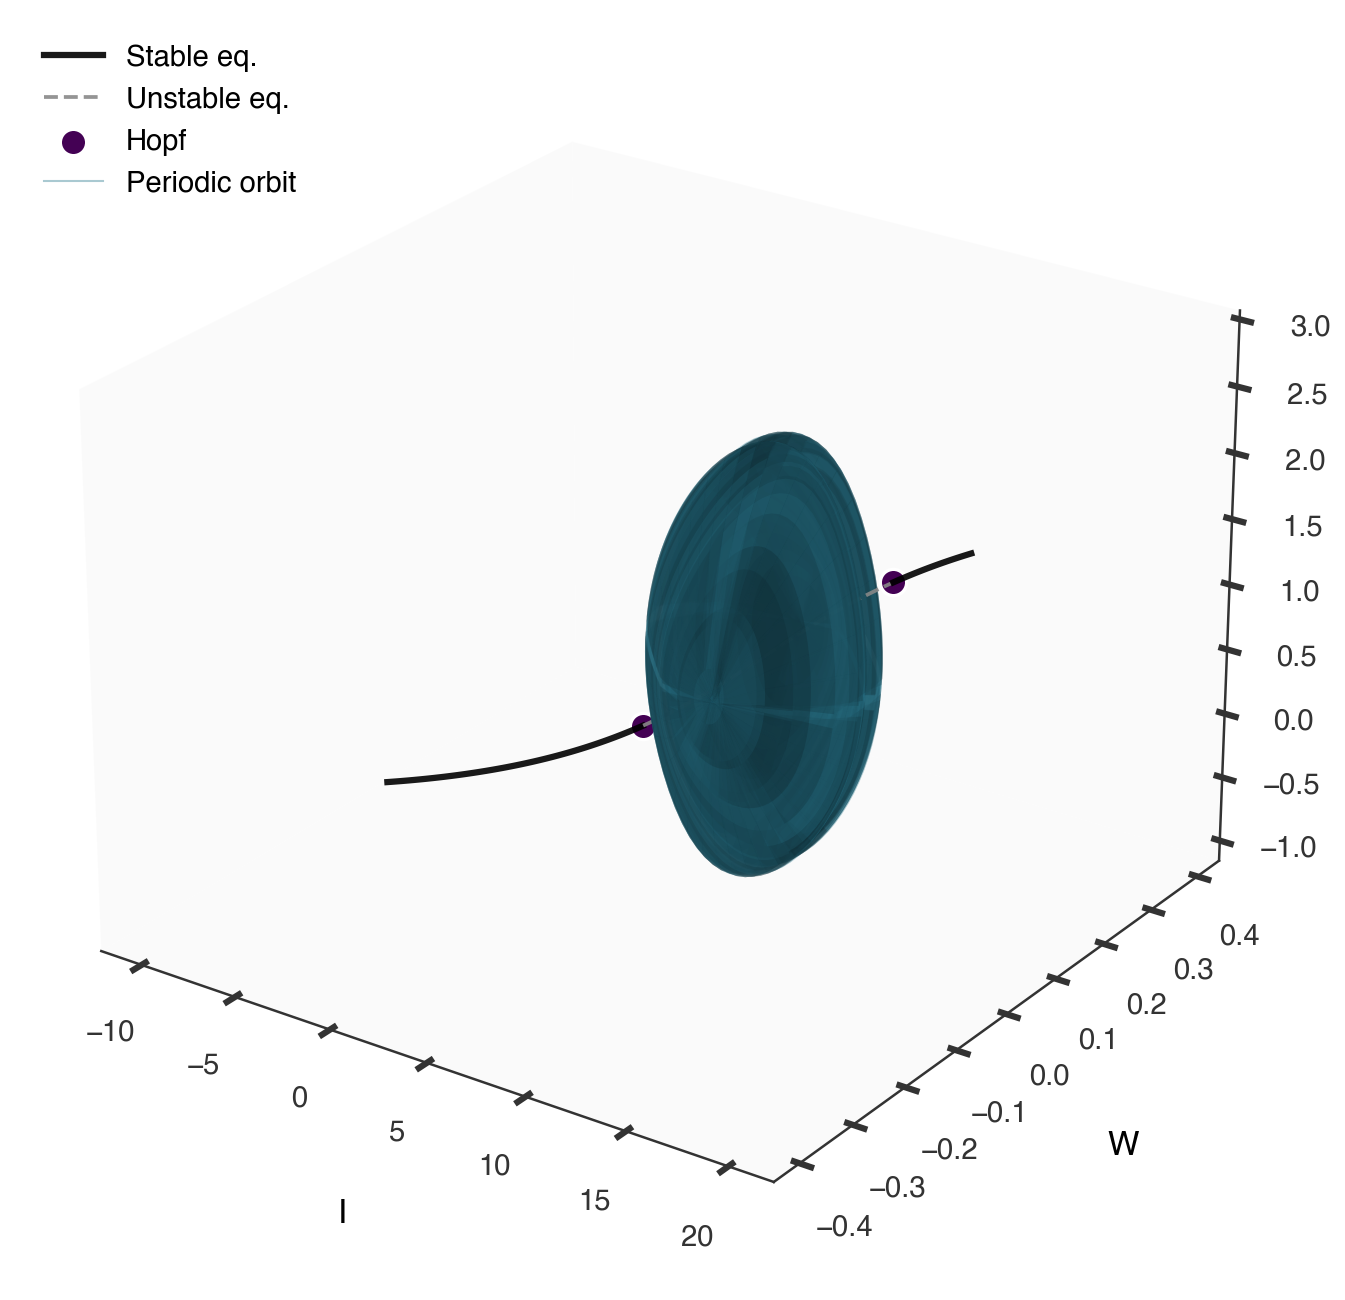

In [12]:
g2d.plot_3d(VOI="V"); plt.show()

**Reading the diagram:** stable branches → resting / persistent
activity; limit cycles → oscillatory regime; folds → abrupt regime
shifts (e.g. seizure onset). The same machinery applied to a whole-brain
network predicts where the *collective* dynamics changes regime as
global coupling or input is varied.

## Exercises

1.  Add a small constant input to the Hopf system:
    `rhs: (a - r**2)*x1 - w*x2 + I0`. Sweep `I0` instead of `a`. What
    kind of bifurcation do you see?
2.  In `Generic2dOscillator`, replace `I` by `b` as the free parameter.
    Where are the Hopf points now?